# Experimenting in TensorFlow and Keras

## Environment setup

In [36]:
from functools import partial
from pathlib import Path

# Suppress all warnings (mostly from Keras recommendations)
import warnings
def warn(*args, **kwargs):
    pass

warnings.warn = warn

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import (
    Conv2D, Dense, GlobalAveragePooling2D,
    Input, MaxPool2D, Flatten, Dropout,
    Rescaling, RandomRotation, RandomFlip, RandomSharpness,
    BatchNormalization, Activation
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.utils import set_random_seed, image_dataset_from_directory

In [3]:
# Define config parameters (copied from config/config.py)

# Global config
RANDOM_SEED = 147

# Project structure
PACKAGE_ROOT = Path("../src/celebrity_faces")
ARTIFACTS_DIR = PACKAGE_ROOT / "artifacts"
DATA_DIR = PACKAGE_ROOT / "data"
METRICS_DIR = PACKAGE_ROOT / "metrics"
MODEL_DIR = PACKAGE_ROOT / "model"

In [4]:
class Pipeline:
    def __init__(self):
        self._layers = {
            "rescaling": Rescaling(1.0 / 255),
            "augmentation": Sequential([
                RandomRotation(0.1),
                RandomFlip("horizontal")
            ]),
        }

        self.train_ds = self._train_pipeline()
        self.val_ds = self._val_pipeline()
        self.test_ds = self._test_pipeline()

    def _train_pipeline(self):
        # Load train set with shuffling
        ds = image_dataset_from_directory(
            DATA_DIR / "train",
            labels="inferred",
            label_mode="int",
            batch_size=BATCH_SIZE,
            image_size=IMAGE_SIZE,
            shuffle=True,
            seed = RANDOM_SEED,
            crop_to_aspect_ratio=True,
            data_format="channels_last",
            verbose=False,
        )
        self.train_labels = ds.class_names

        # Rescale to achieve more stable convergence
        ds = ds.map(
            lambda x, y: (self._layers["rescaling"](x), y),
            num_parallel_calls=1
        )

        return ds

    def _val_pipeline(self):
        # Load validation set without shuffling
        ds = image_dataset_from_directory(
            DATA_DIR / "validation",
            labels="inferred",
            label_mode="int",
            batch_size=BATCH_SIZE,
            image_size=IMAGE_SIZE,
            shuffle=False,
            crop_to_aspect_ratio=True,
            data_format="channels_last",
            verbose=False,
        )
        self.val_labels = ds.class_names

        # Rescale to achieve more stable convergence
        ds = ds.map(
            lambda x, y: (self._layers["rescaling"](x), y),
            num_parallel_calls=1
        )

        return ds

    def _test_pipeline(self):
        # Load test set without shuffling
        ds = image_dataset_from_directory(
            DATA_DIR / "test",
            labels="inferred",
            label_mode="int",
            batch_size=BATCH_SIZE,
            image_size=IMAGE_SIZE,
            shuffle=False,
            crop_to_aspect_ratio=True,
            data_format="channels_last",
            verbose=False,
        )
        self.test_labels = ds.class_names

        # Rescale to achieve more stable convergence
        ds = ds.map(
            lambda x, y: (self._layers["rescaling"](x), y),
            num_parallel_calls=1
        )

        return ds

In [5]:
def train(model, pipeline, optimizer, epochs=50):
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"],
    )

    # Setup callbacks
    #early_stopping_cb = EarlyStopping(
    #    monitor="val_loss", min_delta=0.001, patience=8, restore_best_weights=True
    #)

    history = model.fit(
        pipeline.train_ds,
        epochs=epochs,
        validation_data=pipeline.val_ds,
    #    callbacks=[early_stopping_cb],
    )

    return history

In [6]:
def plot_learning_curves(hist):
    epochs = len(hist.history["loss"])
    fix, ax = plt.subplots(1, 2, figsize=(10, 6))
    ax[0].plot(range(1, epochs+1), hist.history['accuracy'], 'b-', label='Train accuracy')
    ax[0].plot(range(1, epochs+1), hist.history['val_accuracy'], 'r-', label='Validation accuracy')
    ax[0].set(xlabel='Epoch', ylabel='Accuracy')
    ax[0].legend()
    
    ax[1].plot(range(1, epochs+1), hist.history['loss'], 'b-', label='Train loss')
    ax[1].plot(range(1, epochs+1), hist.history['val_loss'], 'r-', label='Validation loss')
    ax[1].set(xlabel='Epoch', ylabel='Loss')
    ax[1].legend()
    
    plt.show()

In [7]:
import os

set_random_seed(RANDOM_SEED)

# TF determinism (TF 2.13+)
tf.config.experimental.enable_op_determinism()

# Optional: make runs identical at the cost of speed
os.environ["TF_DETERMINISTIC_OPS"] = "1"

## Experiment 1

**Minimal Baseline**

We'll do this experiment with the following settings :
- Objective : First intuition about model capacity on a noisy dataset (not preprocessed for face detection)
- Use two single conv blocks (32+64) with image augmentation (IA), using Adam optimizer, no GPU optimization
- Use a 64-node dense layer head with no Dropout
- Try bigger image size first (200x200) if no OOM error, otherwise try medium image size (160x160)
- Try medium (16) or bigger (32) batch size
- Train for 50 epochs without early stopping (GPU)

In [8]:
def baseline_model(in_shape):
    def_conv2d = partial(
        Conv2D,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
        activation="relu",
    )

    augmentation = Sequential([
        RandomRotation(0.1),
        RandomFlip("horizontal"),
    ])
    model = Sequential(
        [
            Input(shape=in_shape),
            augmentation,
            # Conv2D block #1
            def_conv2d(filters=32),
            MaxPool2D(),
            # Conv2D block #2
            def_conv2d(filters=64),
            GlobalAveragePooling2D(),
            Dense(units=64, activation="relu", kernel_initializer="he_normal"),
            # Dropout(0.25),
            Dense(units=10, activation="softmax"),
        ]
    )

    return model

In [9]:
IMAGE_SIZE = (200, 200)
BATCH_SIZE = 16

In [10]:
pipeline = Pipeline()
input_shape = IMAGE_SIZE + (3,)

I0000 00:00:1777531033.432322  942570 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1353 MB memory:  -> device: 0, name: NVIDIA GeForce MX570 A, pci bus id: 0000:01:00.0, compute capability: 8.6


### Train with Adam optimizer

In [15]:
model = baseline_model(input_shape)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,202 (94.54 KB)

 Trainable params: 24,202 (94.54 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
optimizer = Adam(learning_rate=3e-4)
epochs = 50

In [17]:
history = train(model, pipeline, optimizer, epochs)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.0850 - loss: 2.3673 - val_accuracy: 0.1000 - val_loss: 2.3082
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.0850 - loss: 2.3076 - val_accuracy: 0.1100 - val_loss: 2.2955
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.1025 - loss: 2.2989 - val_accuracy: 0.1000 - val_loss: 2.2875
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.1063 - loss: 2.2915 - val_accuracy: 0.1400 - val_loss: 2.2775
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.1025 - loss: 2.2846 - val_accuracy: 0.1900 - val_loss: 2.2674
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1325 - loss: 2.2773 - val_accuracy: 0.1500 - val_loss: 2.2574
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.1363 - loss: 2.2665 - val_accuracy: 0.1200 - val_loss: 2.2517
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.1425 - loss: 2.2522 - val_accuracy: 0.1500 - v

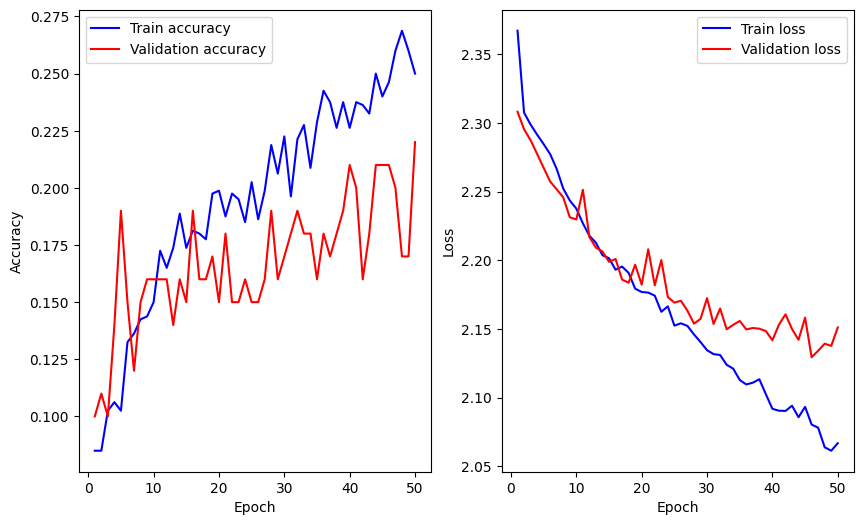

In [18]:
plot_learning_curves(history)

## Experiment 2

**Better Baseline**

We'll do this experiment with the following settings :
- Objective : Inspecting the effects of model capacity vs. optimization
- Use three single conv blocks (32+64+128) with image augmentation (IA), using different optimizers, no GPU optimization
- Use a 64-node dense layer head with no Dropout
- Try bigger image size first (200x200) if no OOM error, otherwise try medium image size (160x160)
- Try medium (16) or bigger (32) batch size
- Train for 50 epochs without early stopping (GPU)

In [21]:
def better_baseline(in_shape):
    def_conv2d = partial(
        Conv2D,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
        activation="relu",
    )

    augmentation = Sequential([
        RandomRotation(0.1),
        RandomFlip("horizontal"),
    ])
    model = Sequential(
        [
            Input(shape=in_shape),
            augmentation,
            # Conv2D block #1
            def_conv2d(filters=32),
            MaxPool2D(),
            # Conv2D block #2
            def_conv2d(filters=64),
            MaxPool2D(),
            # Conv2D block #3
            def_conv2d(filters=128),
            GlobalAveragePooling2D(),
            Dense(units=64, activation="relu", kernel_initializer="he_normal"),
            Dense(units=10, activation="softmax"),
        ]
    )

    return model

### Training with Adam optimizer

In [22]:
model = better_baseline(input_shape)
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,154 (399.04 KB)

 Trainable params: 102,154 (399.04 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
optimizer = Adam(learning_rate=3e-4)
epochs = 30

In [24]:
history = train(model, pipeline, optimizer, epochs)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.0975 - loss: 2.3433 - val_accuracy: 0.1000 - val_loss: 2.3105
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.0975 - loss: 2.3088 - val_accuracy: 0.1000 - val_loss: 2.2896
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.1300 - loss: 2.2877 - val_accuracy: 0.1600 - val_loss: 2.2770
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.1225 - loss: 2.2700 - val_accuracy: 0.1400 - val_loss: 2.2704
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.1388 - loss: 2.2512 - val_accuracy: 0.1100 - val_loss: 2.2715
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.1525 - loss: 2.2363 - val_accuracy: 0.1300 - val_loss: 2.2617
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.1600 - loss: 2.2317 - val_accuracy: 0.1400 - val_loss: 2.3042
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.1525 - loss: 2.2134 - val_accuracy: 0.1100 - v

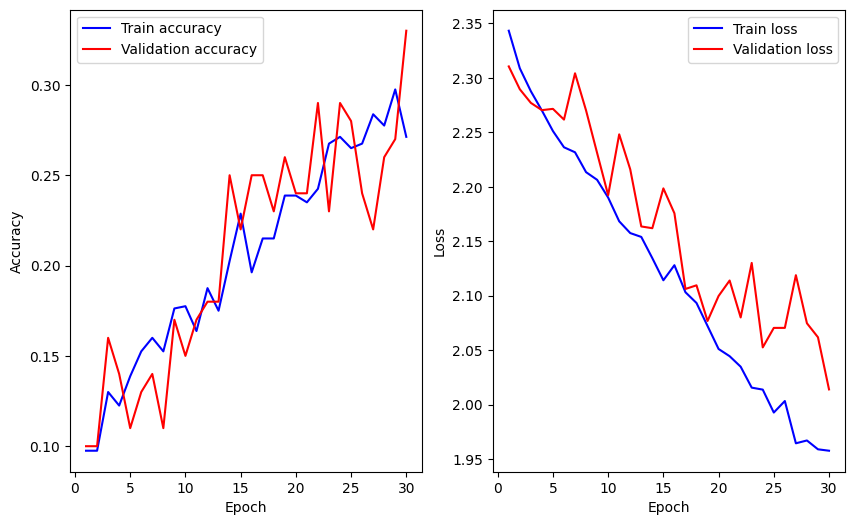

In [25]:
plot_learning_curves(history)

### Training with RMSprop optimizer

In [26]:
model = better_baseline(input_shape)

In [27]:
optimizer = RMSprop(learning_rate=3e-4)
epochs = 30

In [28]:
history = train(model, pipeline, optimizer, epochs)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.0825 - loss: 2.3343 - val_accuracy: 0.1000 - val_loss: 2.3201
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.1088 - loss: 2.2928 - val_accuracy: 0.1400 - val_loss: 2.2784
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.1200 - loss: 2.2738 - val_accuracy: 0.1200 - val_loss: 2.2760
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.1388 - loss: 2.2736 - val_accuracy: 0.1300 - val_loss: 2.2914
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.1475 - loss: 2.2539 - val_accuracy: 0.1600 - val_loss: 2.2734
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.1412 - loss: 2.2427 - val_accuracy: 0.1600 - val_loss: 2.2717
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1513 - loss: 2.2337 - val_accuracy: 0.1000 - val_loss: 2.3038
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.1625 - loss: 2.2264 - val_accuracy: 0.1400 - v

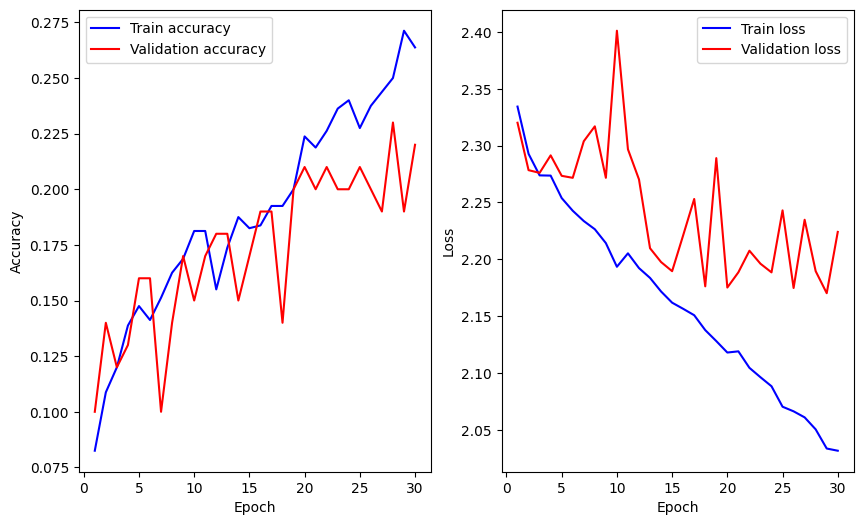

In [29]:
plot_learning_curves(history)

### Training with SGD optimizer

In [30]:
model = better_baseline(input_shape)

In [31]:
optimizer = SGD(learning_rate=0.01, momentum=0.9)
epochs = 30

In [32]:
history = train(model, pipeline, optimizer, epochs)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.0975 - loss: 2.3230 - val_accuracy: 0.1000 - val_loss: 2.2967
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.0975 - loss: 2.3037 - val_accuracy: 0.1100 - val_loss: 2.2931
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.0900 - loss: 2.3032 - val_accuracy: 0.1000 - val_loss: 2.2896
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.0988 - loss: 2.2981 - val_accuracy: 0.1500 - val_loss: 2.2811
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.1163 - loss: 2.2871 - val_accuracy: 0.1300 - val_loss: 2.2949
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.1100 - loss: 2.2849 - val_accuracy: 0.0800 - val_loss: 2.2702
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.1363 - loss: 2.2584 - val_accuracy: 0.1300 - val_loss: 2.2437
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.1388 - loss: 2.2561 - val_accuracy: 0.1400 - v

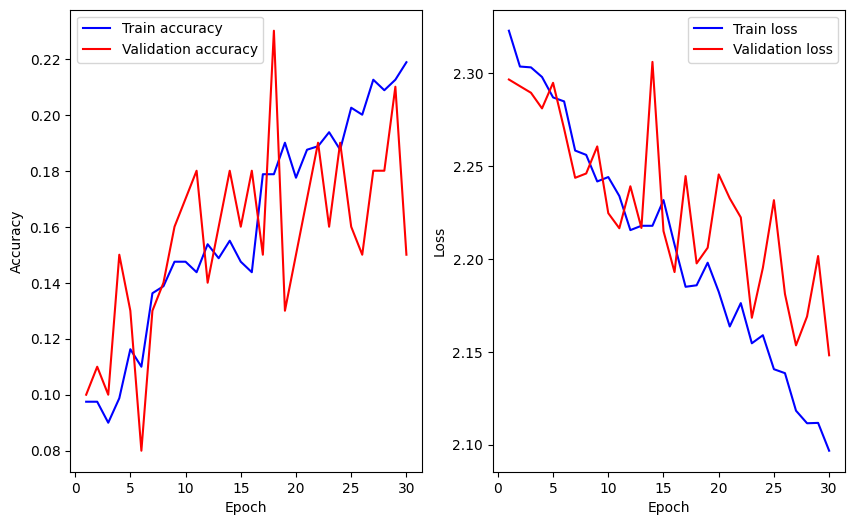

In [34]:
plot_learning_curves(history)

## Experiment 3

**Regularization**

We'll do this experiment with the following settings :
- Objective : Inspecting the effects of regularization and augmentation
- Use three single conv blocks (32+64+128), same as previous experiment
- Only add dropout to head (0.3)
- Only add random sharpness to IA
- Add both dropout and random sharpness
- Train for 30 epochs with Adam (GPU)

In [37]:
def fit(model, pipeline, epochs=30):
    optimizer = Adam(learning_rate=3e-4)
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"],
    )

    history = model.fit(
        pipeline.train_ds,
        epochs=epochs,
        validation_data=pipeline.val_ds,
    )

    return history

### New baseline

In [38]:
def new_baseline(in_shape):
    def_conv2d = partial(
        Conv2D,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
        activation="relu",
    )

    augmentation = Sequential([
        RandomRotation(0.1),
        RandomFlip("horizontal"),
    ])
    model = Sequential(
        [
            Input(shape=in_shape),
            augmentation,
            # Conv2D block #1
            def_conv2d(filters=32),
            MaxPool2D(),
            # Conv2D block #2
            def_conv2d(filters=64),
            MaxPool2D(),
            # Conv2D block #3
            def_conv2d(filters=128),
            GlobalAveragePooling2D(),
            Dense(units=64, activation="relu", kernel_initializer="he_normal"),
            Dense(units=10, activation="softmax"),
        ]
    )

    return model

In [39]:
model = new_baseline(input_shape)
history = fit(model, pipeline)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.1000 - loss: 2.3581 - val_accuracy: 0.1100 - val_loss: 2.3014
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.1138 - loss: 2.3096 - val_accuracy: 0.0900 - val_loss: 2.2847
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.1312 - loss: 2.2867 - val_accuracy: 0.1300 - val_loss: 2.2738
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.1325 - loss: 2.2692 - val_accuracy: 0.1400 - val_loss: 2.2697
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.1550 - loss: 2.2600 - val_accuracy: 0.1400 - val_loss: 2.2278
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.1787 - loss: 2.2279 - val_accuracy: 0.1500 - val_loss: 2.2469
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.1775 - loss: 2.2345 - val_accuracy: 0.1600 - val_loss: 2.2187
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.1587 - loss: 2.2094 - val_accuracy: 0.1400 - v

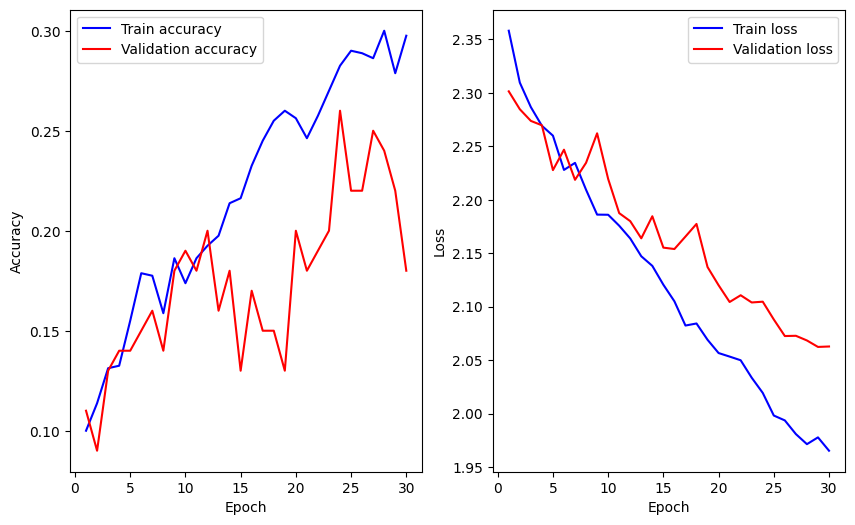

In [40]:
plot_learning_curves(history)

### Baseline with dropout

In [41]:
def new_baseline_dropout(in_shape):
    def_conv2d = partial(
        Conv2D,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
        activation="relu",
    )

    augmentation = Sequential([
        RandomRotation(0.1),
        RandomFlip("horizontal"),
    ])
    model = Sequential(
        [
            Input(shape=in_shape),
            augmentation,
            # Conv2D block #1
            def_conv2d(filters=32),
            MaxPool2D(),
            # Conv2D block #2
            def_conv2d(filters=64),
            MaxPool2D(),
            # Conv2D block #3
            def_conv2d(filters=128),
            GlobalAveragePooling2D(),
            Dense(units=64, activation="relu", kernel_initializer="he_normal"),
            Dropout(0.3),
            Dense(units=10, activation="softmax"),
        ]
    )

    return model

In [42]:
model = new_baseline_dropout(input_shape)
history = fit(model, pipeline)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.1088 - loss: 2.3215 - val_accuracy: 0.1200 - val_loss: 2.2885
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.1163 - loss: 2.2963 - val_accuracy: 0.1300 - val_loss: 2.2802
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.1000 - loss: 2.2895 - val_accuracy: 0.1300 - val_loss: 2.2723
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.1187 - loss: 2.2743 - val_accuracy: 0.1300 - val_loss: 2.2745
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.1275 - loss: 2.2643 - val_accuracy: 0.1500 - val_loss: 2.2627
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.1437 - loss: 2.2425 - val_accuracy: 0.1200 - val_loss: 2.2705
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.1437 - loss: 2.2278 - val_accuracy: 0.1400 - val_loss: 2.2312
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.1350 - loss: 2.2366 - val_accuracy: 0.1600 - v

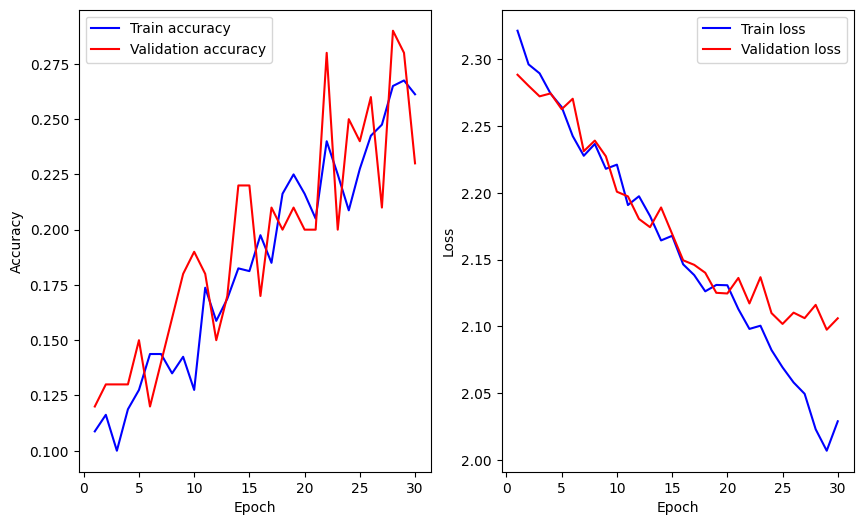

In [43]:
plot_learning_curves(history)

### Baseline with improved augmentation

In [45]:
def new_baseline_augment(in_shape):
    def_conv2d = partial(
        Conv2D,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
        activation="relu",
    )

    augmentation = Sequential([
        RandomSharpness(factor=0.4, value_range=[0, 1]), # Slight blur (close to 0.5: No Blur)
        RandomRotation(0.1),
        RandomFlip("horizontal"),
    ])
    model = Sequential(
        [
            Input(shape=in_shape),
            augmentation,
            # Conv2D block #1
            def_conv2d(filters=32),
            MaxPool2D(),
            # Conv2D block #2
            def_conv2d(filters=64),
            MaxPool2D(),
            # Conv2D block #3
            def_conv2d(filters=128),
            GlobalAveragePooling2D(),
            Dense(units=64, activation="relu", kernel_initializer="he_normal"),
            Dense(units=10, activation="softmax"),
        ]
    )

    return model

In [46]:
model = new_baseline_augment(input_shape)
history = fit(model, pipeline)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.1112 - loss: 2.3151 - val_accuracy: 0.1100 - val_loss: 2.2904
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.1287 - loss: 2.2899 - val_accuracy: 0.1300 - val_loss: 2.2702
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.1238 - loss: 2.2829 - val_accuracy: 0.1100 - val_loss: 2.2542
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.1462 - loss: 2.2473 - val_accuracy: 0.1200 - val_loss: 2.2353
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.1513 - loss: 2.2291 - val_accuracy: 0.1400 - val_loss: 2.2368
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.1462 - loss: 2.2166 - val_accuracy: 0.1500 - val_loss: 2.2094
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.1663 - loss: 2.1958 - val_accuracy: 0.1200 - val_loss: 2.2257
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.1813 - loss: 2.1975 - val_accuracy: 0.1400 - v

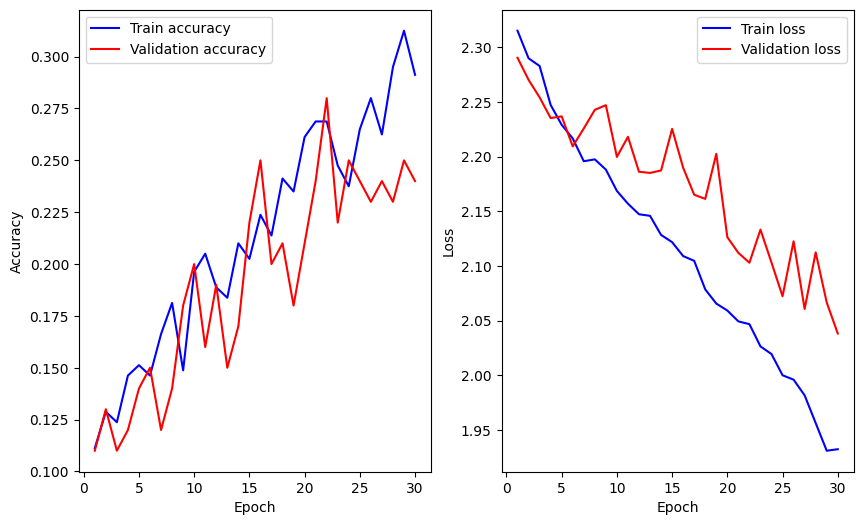

In [47]:
plot_learning_curves(history)

### Baseline with dropout and augmentation

In [48]:
def new_baseline_dropout_augment(in_shape):
    def_conv2d = partial(
        Conv2D,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
        activation="relu",
    )

    augmentation = Sequential([
        RandomSharpness(factor=0.4, value_range=[0, 1]), # Slight blur (close to 0.5: No Blur)
        RandomRotation(0.1),
        RandomFlip("horizontal"),
    ])
    model = Sequential(
        [
            Input(shape=in_shape),
            augmentation,
            # Conv2D block #1
            def_conv2d(filters=32),
            MaxPool2D(),
            # Conv2D block #2
            def_conv2d(filters=64),
            MaxPool2D(),
            # Conv2D block #3
            def_conv2d(filters=128),
            GlobalAveragePooling2D(),
            Dense(units=64, activation="relu", kernel_initializer="he_normal"),
            Dropout(0.3),
            Dense(units=10, activation="softmax"),
        ]
    )

    return model

In [49]:
model = new_baseline_dropout_augment(input_shape)
history = fit(model, pipeline)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.1037 - loss: 2.3454 - val_accuracy: 0.1400 - val_loss: 2.2971
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.1000 - loss: 2.3030 - val_accuracy: 0.1100 - val_loss: 2.2970
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.1075 - loss: 2.2995 - val_accuracy: 0.1300 - val_loss: 2.2812
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.1187 - loss: 2.2801 - val_accuracy: 0.1000 - val_loss: 2.2812
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.1213 - loss: 2.2808 - val_accuracy: 0.1000 - val_loss: 2.2589
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.1412 - loss: 2.2628 - val_accuracy: 0.1300 - val_loss: 2.2516
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.1762 - loss: 2.2428 - val_accuracy: 0.1000 - val_loss: 2.2445
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.1538 - loss: 2.2246 - val_accuracy: 0.1200 - v

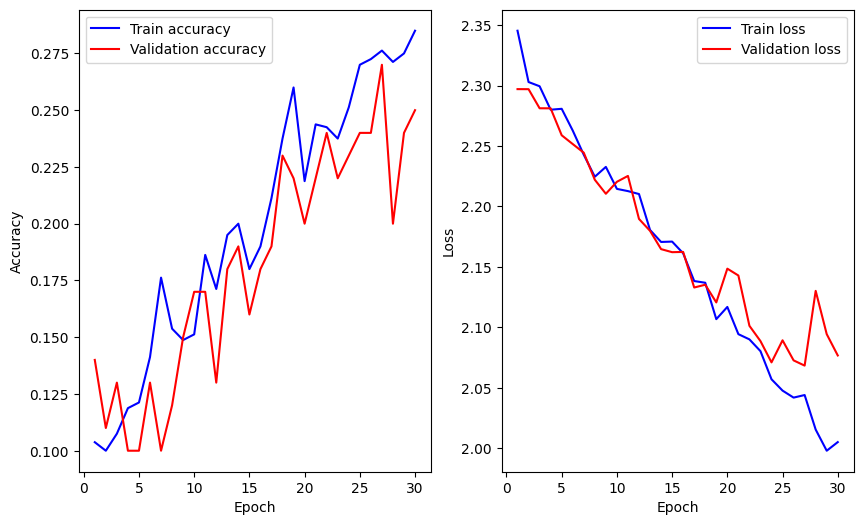

In [50]:
plot_learning_curves(history)